In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('hmeq.csv')

In [ ]:
df.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN


In [ ]:
df.dtypes

BAD          int64
LOAN         int64
MORTDUE    float64
VALUE      float64
REASON      object
JOB         object
YOJ        float64
DEROG      float64
DELINQ     float64
CLAGE      float64
NINQ       float64
CLNO       float64
DEBTINC    float64
dtype: object

In [ ]:
df.describe()

,BAD,LOAN,MORTDUE,VALUE,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC
count,5960.000000,5960.000000,5442.000000,5848.000000,5445.000000,5252.000000,5380.000000,5652.000000,5450.000000,5738.000000,4693.000000
mean,0.199497,18607.969799,73760.817200,101776.048741,8.922268,0.254570,0.449442,179.766275,1.186055,21.296096,33.779915
std,0.399656,11207.480417,44457.609458,57385.775334,7.573982,0.846047,1.127266,85.810092,1.728675,10.138933,8.601746
min,0.000000,1100.000000,2063.000000,8000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.524499
25%,0.000000,11100.000000,46276.000000,66075.500000,3.000000,0.000000,0.000000,115.116702,0.000000,15.000000,29.140031
50%,0.000000,16300.000000,65019.000000,89235.500000,7.000000,0.000000,0.000000,173.466667,1.000000,20.000000,34.818262
75%,0.000000,23300.000000,91488.000000,119824.250000,13.000000,0.000000,0.000000,231.562278,2.000000,26.000000,39.003141
max,1.000000,89900.000000,399550.000000,855909.000000,41.000000,10.000000,15.000000,1168.233561,17.000000,71.000000,203.312149


Total number of rows should be 5960, we can tell there are many missing values in variables except for 'BAD' and 'LOAN'.

In [ ]:
#to find out what's missing
missing_MORTDUE = df['MORTDUE'].isnull().sum()
missing_VALUE = df['VALUE'].isnull().sum()
missing_REASON = df['REASON'].isnull().sum()
missing_JOB = df['JOB'].isnull().sum()
missing_YOJ = df['YOJ'].isnull().sum()
missing_DEROG = df['DEROG'].isnull().sum()
missing_DELINQ = df['DELINQ'].isnull().sum()
missing_CLAGE = df['CLAGE'].isnull().sum()
missing_NINQ = df['NINQ'].isnull().sum()
missing_CLNO = df['CLNO'].isnull().sum()
missing_DEBTINC = df['DEBTINC'].isnull().sum()

In [ ]:
print('missing mortgage due: ', missing_MORTDUE,'% missing: ', missing_MORTDUE/5960)
print('missing Home value: ', missing_VALUE,'% missing: ', missing_VALUE/5960)
print('missing Reason for loan: ', missing_REASON,'% missing: ', missing_REASON/5960)
print('missing Job: ', missing_JOB,'% missing: ', missing_JOB/5960)
print('missing year of job: ', missing_YOJ,'% missing: ', missing_YOJ/5960)
print('missing number of major derogatory reports: ', missing_DEROG,'% missing: ', missing_DEROG/5960)
print('missing number of delinquent credit lines: ', missing_DELINQ,'% missing: ', missing_DELINQ/5960)
print('missing age of oldest credit line in months: ', missing_CLAGE,'% missing: ', missing_CLAGE/5960)
print('missing number of recent credit inquiries: ', missing_NINQ,'% missing: ', missing_NINQ/5960)
print('missing Number of credit lines: ', missing_CLNO,'% missing: ', missing_CLNO/5960)
print('missing debt-to-income ratio: ', missing_DEBTINC,'% missing: ', missing_DEBTINC/5960)

missing mortgage due:  518 % missing:  0.08691275167785235
missing Home value:  112 % missing:  0.01879194630872483
missing Reason for loan:  252 % missing:  0.042281879194630875
missing Job:  279 % missing:  0.04681208053691275
missing year of job:  515 % missing:  0.08640939597315436
missing number of major derogatory reports:  708 % missing:  0.11879194630872483
missing number of delinquent credit lines:  580 % missing:  0.09731543624161074
missing age of oldest credit line in months:  308 % missing:  0.05167785234899329
missing number of recent credit inquiries:  510 % missing:  0.08557046979865772
missing Number of credit lines:  222 % missing:  0.03724832214765101
missing debt-to-income ratio:  1267 % missing:  0.21258389261744967


In [ ]:
df['count_na']=df.isnull().sum(axis=1)
df

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,count_na
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN,1
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN,1
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN,1
3,1,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347,0
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971,0
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590,0
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882,0


In [ ]:
df2 = df

In [ ]:
#filter out feature and label that has more than 20% missing data
df2.dropna(axis=0, thresh=0.8*df.shape[1], inplace=True)
df2

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,count_na
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN,1
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN,1
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN,1
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN,1
5,1,1700,30548.0,40320.0,HomeImp,Other,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347,0
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971,0
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590,0
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882,0


In [ ]:
#count number of 'bad' as 1 and 0
df2['BAD'].value_counts()

BAD
0    4316
1    1086
Name: count, dtype: int64

In [ ]:
#create a new column to show whether 'DEBTINC' is available, show as 1 if available, 0 if not available
df2['DEBTINC_AVAIL'] = df2['DEBTINC'].notnull().astype('int')
df2['DEBTINC_AVAIL'].value_counts()

DEBTINC_AVAIL
1    4287
0    1115
Name: count, dtype: int64

In [ ]:
#create a new column to show whether value is more than mortgage due and loan, show as 1 if yes, 0 if no
df2['VALUE_MORE'] = (df2['VALUE'] > df2['MORTDUE']) & (df2['VALUE'] > df2['LOAN'])
df2['VALUE_MORE'] = df2['VALUE_MORE'].astype('int')
df2['VALUE_MORE'].value_counts()

VALUE_MORE
1    5012
0     390
Name: count, dtype: int64

In [ ]:
df2 = df2[['BAD', 'LOAN', 'MORTDUE', 'VALUE', 'REASON', 'JOB', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'CLNO', 'DEBTINC', 'DEBTINC_AVAIL', 'VALUE_MORE', 'count_na']]
df2.head()

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,DEBTINC_AVAIL,VALUE_MORE,count_na
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN,0,1,1
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN,0,0,1
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN,0,1,1
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN,0,1,1
5,1,1700,30548.0,40320.0,HomeImp,Other,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614,1,1,0


In [ ]:
df2

,BAD,LOAN,MORTDUE,VALUE,REASON,JOB,YOJ,DEROG,DELINQ,CLAGE,NINQ,CLNO,DEBTINC,DEBTINC_AVAIL,VALUE_MORE,count_na
0,1,1100,25860.0,39025.0,HomeImp,Other,10.5,0.0,0.0,94.366667,1.0,9.0,NaN,0,1,1
1,1,1300,70053.0,68400.0,HomeImp,Other,7.0,0.0,2.0,121.833333,0.0,14.0,NaN,0,0,1
2,1,1500,13500.0,16700.0,HomeImp,Other,4.0,0.0,0.0,149.466667,1.0,10.0,NaN,0,1,1
4,0,1700,97800.0,112000.0,HomeImp,Office,3.0,0.0,0.0,93.333333,0.0,14.0,NaN,0,1,1
5,1,1700,30548.0,40320.0,HomeImp,Other,9.0,0.0,0.0,101.466002,1.0,8.0,37.113614,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5955,0,88900,57264.0,90185.0,DebtCon,Other,16.0,0.0,0.0,221.808718,0.0,16.0,36.112347,1,1,0
5956,0,89000,54576.0,92937.0,DebtCon,Other,16.0,0.0,0.0,208.692070,0.0,15.0,35.859971,1,1,0
5957,0,89200,54045.0,92924.0,DebtCon,Other,15.0,0.0,0.0,212.279697,0.0,15.0,35.556590,1,1,0
5958,0,89800,50370.0,91861.0,DebtCon,Other,14.0,0.0,0.0,213.892709,0.0,16.0,34.340882,1,1,0


In [ ]:
df2['JOB'] = df2['JOB'].fillna('Unknown')
df2['REASON'] = df2['REASON'].fillna('Unknown')

df2 = pd.get_dummies(df2, columns=['JOB', 'REASON'], drop_first=True)

In [ ]:
df2.corr()['BAD'].sort_values()

DEBTINC_AVAIL    -0.541921
CLAGE            -0.176994
VALUE_MORE       -0.102790
JOB_Office       -0.082792
LOAN             -0.076803
YOJ              -0.074471
MORTDUE          -0.054307
JOB_ProfExe      -0.051729
JOB_Unknown      -0.050880
VALUE            -0.042800
CLNO             -0.008815
REASON_HomeImp    0.020438
REASON_Unknown    0.024471
JOB_Self          0.038926
JOB_Sales         0.050448
JOB_Other         0.066003
NINQ              0.172868
DEBTINC           0.209440
DEROG             0.295131
count_na          0.334273
DELINQ            0.346494
BAD               1.000000
Name: BAD, dtype: float64

### Split into train set and test set

In [ ]:
X = df2.drop('BAD', axis=1)
y = df2['BAD']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))


BAD
0    0.798889
1    0.201111
Name: proportion, dtype: float64
BAD
0    0.79926
1    0.20074
Name: proportion, dtype: float64


In [ ]:
cols_with_missing = X.columns[X.isnull().any()].tolist()
cols_with_missing

['MORTDUE', 'VALUE', 'YOJ', 'DEROG', 'DELINQ', 'CLAGE', 'NINQ', 'DEBTINC']

## Now do imputation

### 1. use MICE

In [ ]:
# using mice to impute missing data
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

MICE_imp = IterativeImputer(random_state=42)
X_train_MICE = MICE_imp.fit_transform(X_train)
X_test_MICE = MICE_imp.transform(X_test)


/Users/lynn/Library/Python/3.9/lib/python/site-packages/sklearn/impute/_iterative.py:801: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_MICE2 = scaler.fit_transform(X_train_MICE)
X_test_MICE2 = scaler.transform(X_test_MICE)

In [ ]:
# save X_train into a dataframe
X_train_MICE_imputed2 = pd.DataFrame(X_train_MICE2, columns=X.columns)
X_train_MICE_imputed2['BAD'] = y_train.tolist()
X_train_MICE_imputed2.to_csv('X_train_mice_imputed_with_scaler.csv', index=False)

In [ ]:
# save X_test into a dataframe
X_test_MICE_imputed2 = pd.DataFrame(X_test_MICE2, columns=X.columns)
X_test_MICE_imputed2['BAD'] = y_test.tolist()
X_test_MICE_imputed2.to_csv('X_test_mice_imputed_with_scaler.csv', index=False)

### 2. Use KNN imputer

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# KNN imputer
from sklearn.impute import KNNImputer
knn_imp = KNNImputer(n_neighbors=5)
X_train_KNN = knn_imp.fit_transform(X_train)
X_test_KNN = knn_imp.transform(X_test)

In [ ]:
X_train_KNN2 = scaler.fit_transform(X_train_KNN)
X_test_KNN2 = scaler.transform(X_test_KNN)

In [ ]:
# save X_train into a dataframe
X_train_knn_imputed = pd.DataFrame(X_train_KNN2, columns=X.columns)
X_train_knn_imputed['BAD'] = y_train.tolist()
X_train_knn_imputed.to_csv('X_train_knn_imputed_with_scaler.csv', index=False)

In [ ]:
# save X_test into a dataframe
X_test_knn_imputed = pd.DataFrame(X_test_KNN2, columns=X.columns)
X_test_knn_imputed['BAD'] = y_test.tolist()
X_test_knn_imputed.to_csv('X_test_knn_imputed_with_scaler.csv', index=False)

# Data Exploration

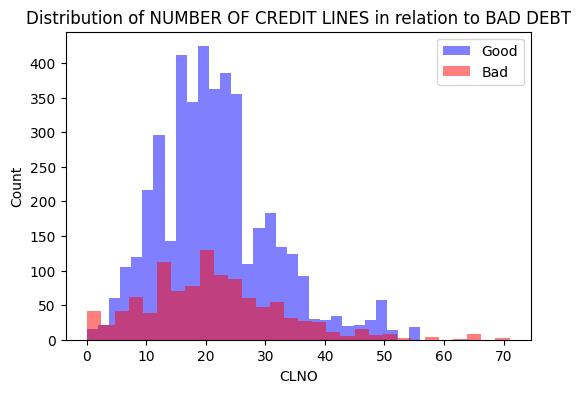

In [ ]:
#plot the distribution of 'bad' result in relation to 'CLNO' in one graph - NUMBER OF CREDIT LINES
plt.figure(figsize=(6,4))
plt.hist(df2[df2['BAD']==0]['CLNO'], bins=30, color='blue', label='Good', alpha=0.5)
plt.hist(df2[df2['BAD']==1]['CLNO'], bins=30, color='red', label='Bad', alpha=0.5)
plt.legend()
plt.xlabel('CLNO')
plt.ylabel('Count')
plt.title('Distribution of NUMBER OF CREDIT LINES in relation to BAD DEBT')
plt.show()

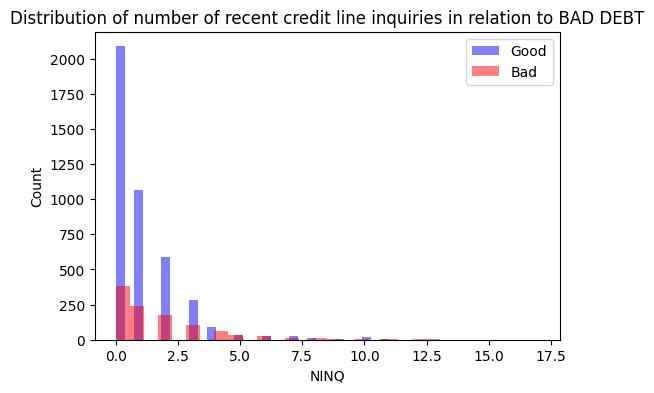

In [ ]:
#plot the distribution of 'bad' result in relation to 'NINQ' in one graph - number of recent credit line inquiries
plt.figure(figsize=(6,4))
plt.hist(df2[df2['BAD']==0]['NINQ'], bins=30, color='blue', label='Good', alpha=0.5)
plt.hist(df2[df2['BAD']==1]['NINQ'], bins=30, color='red', label='Bad', alpha=0.5)
plt.legend()
plt.xlabel('NINQ')
plt.ylabel('Count')
plt.title('Distribution of number of recent credit line inquiries in relation to BAD DEBT')
plt.show()



Applicant has more number of recent credit line inquiries indicates a higher likelyhood of bad debt.

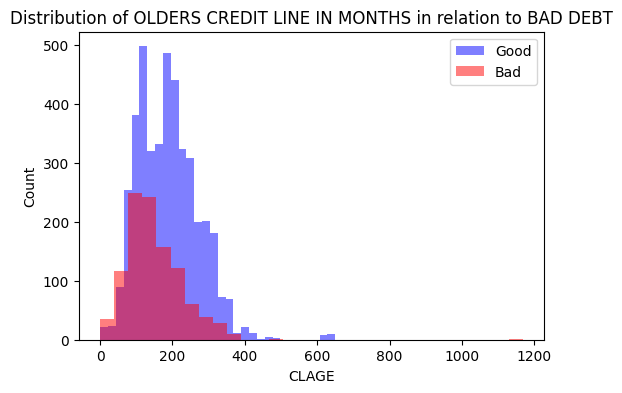

In [ ]:
#plot the distribution of 'bad' result in relation to 'CLAGE' in one graph - OLDERS CREDIT LINE IN MONTHS
plt.figure(figsize=(6,4))
plt.hist(df2[df2['BAD']==0]['CLAGE'], bins=30, color='blue', label='Good', alpha=0.5)
plt.hist(df2[df2['BAD']==1]['CLAGE'], bins=30, color='red', label='Bad', alpha=0.5)
plt.legend()
plt.xlabel('CLAGE')
plt.ylabel('Count')
plt.title('Distribution of OLDERS CREDIT LINE IN MONTHS in relation to BAD DEBT')
plt.show()

applicants have higher CLAGE (older credit lines) are more likely to have good debts compare to applicants have lower CLAGE.

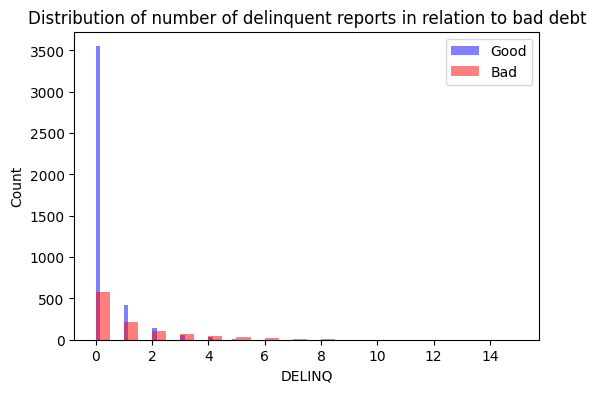

In [ ]:
#plot the distribution of 'bad' result in relation to 'DELINQ' in one graph - number of derogatory reports
plt.figure(figsize=(6,4))
plt.hist(df2[df2['BAD']==0]['DELINQ'], bins=30, color='blue', label='Good', alpha=0.5)
plt.hist(df2[df2['BAD']==1]['DELINQ'], bins=30, color='red', label='Bad', alpha=0.5)
plt.legend()
plt.xlabel('DELINQ')
plt.ylabel('Count')
plt.title('Distribution of number of delinquent reports in relation to bad debt')
plt.show()


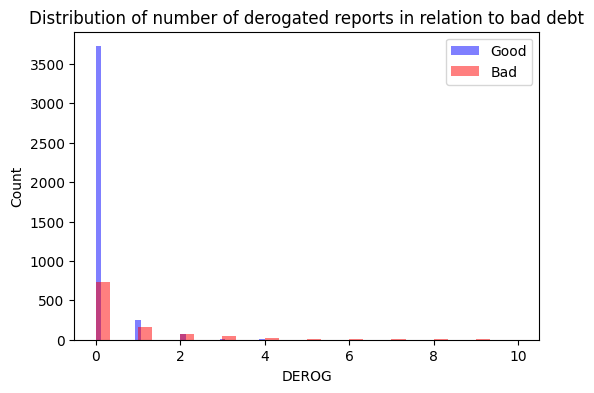

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df2[df2['BAD']==0]['DEROG'], bins=30, color='blue', label='Good', alpha=0.5)
plt.hist(df2[df2['BAD']==1]['DEROG'], bins=30, color='red', label='Bad', alpha=0.5)
plt.legend()
plt.xlabel('DEROG')
plt.ylabel('Count')
plt.title('Distribution of number of derogated reports in relation to bad debt')
plt.show()

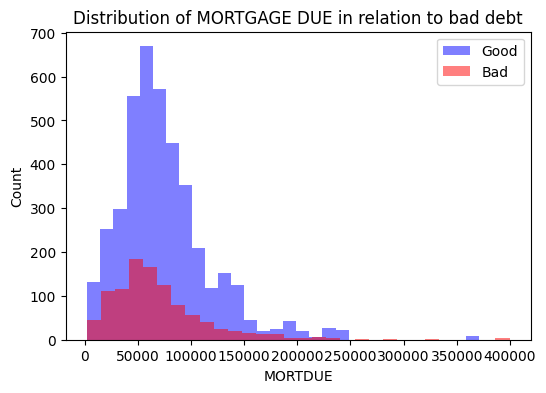

In [ ]:
#plot the distribution of 'bad' result in relation to 'MORTDUE' in one graph - number of derogatory reports
plt.figure(figsize=(6,4))
plt.hist(df2[df2['BAD']==0]['MORTDUE'], bins=30, color='blue', label='Good', alpha=0.5)
plt.hist(df2[df2['BAD']==1]['MORTDUE'], bins=30, color='red', label='Bad', alpha=0.5)
plt.legend()
plt.xlabel('MORTDUE')
plt.ylabel('Count')
plt.title('Distribution of MORTGAGE DUE in relation to bad debt')
plt.show()


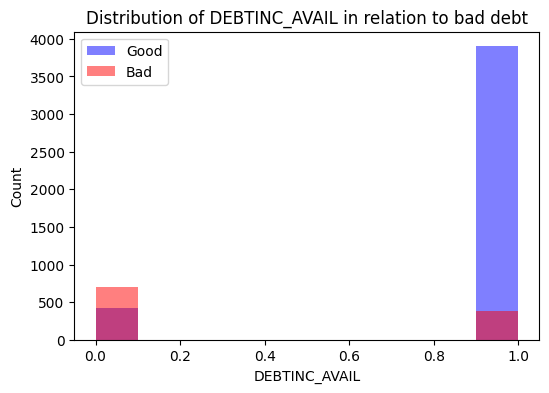

In [ ]:
#plot the distribution of 'bad' result in relation to 'DEBTINC_AVAIL' in one graph - WHETHER DEBTINC IS AVAILABLE
plt.figure(figsize=(6,4))
plt.hist(df2[df2['BAD']==0]['DEBTINC_AVAIL'], color='blue', label='Good', alpha=0.5)
plt.hist(df2[df2['BAD']==1]['DEBTINC_AVAIL'], color='red', label='Bad', alpha=0.5)
plt.legend()
plt.xlabel('DEBTINC_AVAIL')
plt.ylabel('Count')
plt.title('Distribution of DEBTINC_AVAIL in relation to bad debt')
plt.show()

Applicants that have/submitted debt-to-income information are less likely to have bad debt

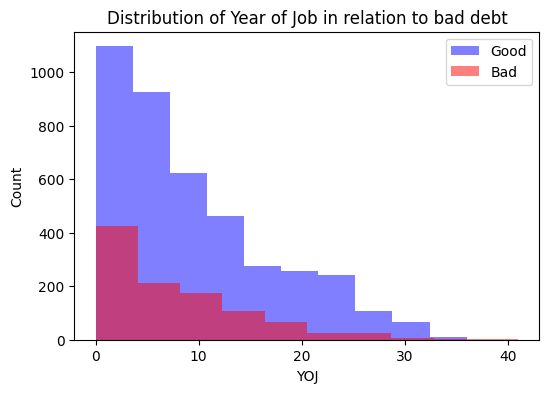

In [ ]:
#relationship between YOJ and BAD
plt.figure(figsize=(6,4))
plt.hist(df2[df2['BAD']==0]['YOJ'], color='blue', label='Good', alpha=0.5)
plt.hist(df2[df2['BAD']==1]['YOJ'], color='red', label='Bad', alpha=0.5)
plt.legend()
plt.xlabel('YOJ')
plt.ylabel('Count')
plt.title('Distribution of Year of Job in relation to bad debt')
plt.show()


no significant relationship

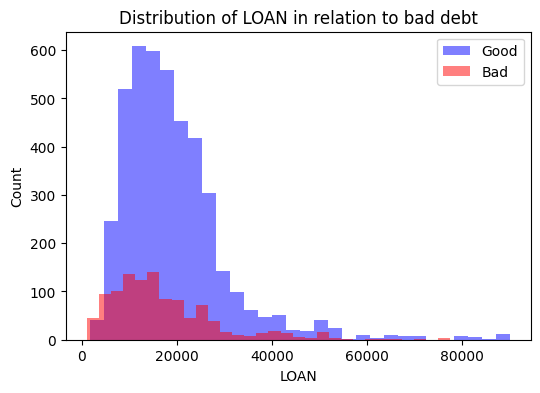

In [ ]:
#visualize the relationship between 'bad' and 'LOAN' in one graph
plt.figure(figsize=(6,4))
plt.hist(df2[df2['BAD']==0]['LOAN'], bins=30, color='blue', label='Good', alpha=0.5)
plt.hist(df2[df2['BAD']==1]['LOAN'], bins=30, color='red', label='Bad', alpha=0.5)
plt.legend()
plt.xlabel('LOAN')
plt.ylabel('Count')
plt.title('Distribution of LOAN in relation to bad debt')
plt.show()
